## Question 1: Fragment Length Frequency and Rescaling

This question involves analyzing DNA fragment data to:
1. Calculate the normalized frequency distribution of fragment lengths
2. Implement a rescaling algorithm to match a reference distribution

### Part 1: Fragment Length Frequency Analysis

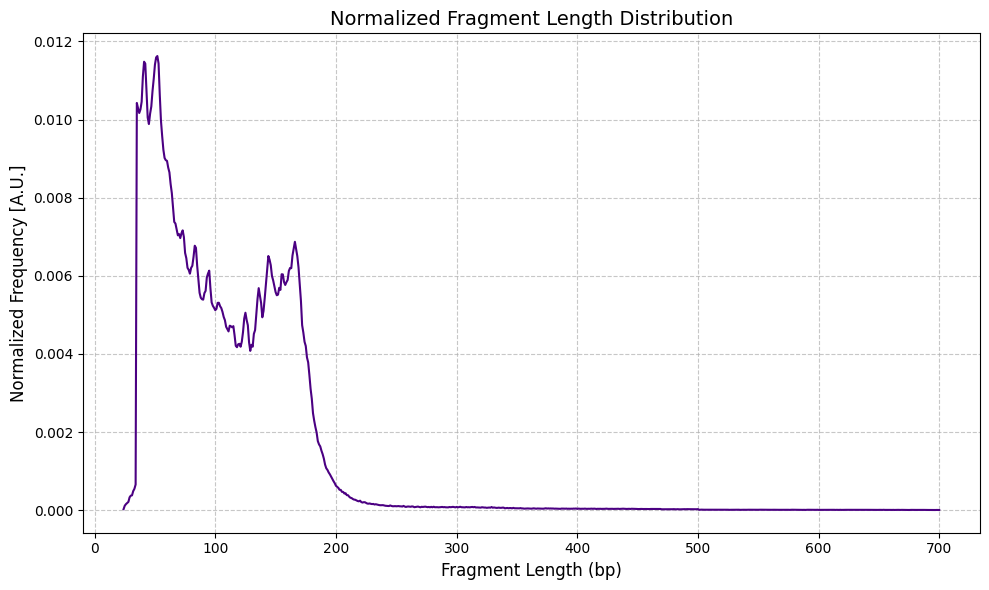

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

fragment_data = pd.read_csv('query.bed', sep='\t', header=None, low_memory=False)

fragment_lengths = fragment_data.iloc[:, 2] - fragment_data.iloc[:, 1]

length_distribution = defaultdict(int)
for length in fragment_lengths:
    length_distribution[length] += 1

total_fragments = sum(length_distribution.values())

normalized_distribution = {}
for length, count in length_distribution.items():
    normalized_distribution[length] = count / total_fragments

lengths, frequencies = zip(*sorted(normalized_distribution.items()))
fragment_distribution = pd.DataFrame({
    'Fragment_Length': lengths,
    'Normalized_Frequency': frequencies
})

plt.figure(figsize=(10, 6))
plt.plot(fragment_distribution['Fragment_Length'], 
         fragment_distribution['Normalized_Frequency'], 
         color='indigo', linewidth=1.5)
plt.xlabel('Fragment Length (bp)', fontsize=12)
plt.ylabel('Normalized Frequency [A.U.]', fontsize=12)
plt.title('Normalized Fragment Length Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Part 2: Distribution Rescaling

Now we need to rescale our query distribution to match a reference distribution.

#### Algorithm Overview:
1. Load reference distribution data
2. Define bins for both distributions
3. Group data points into bins
4. For each bin, sample the minimum number of points between query and reference
5. Visualize the results

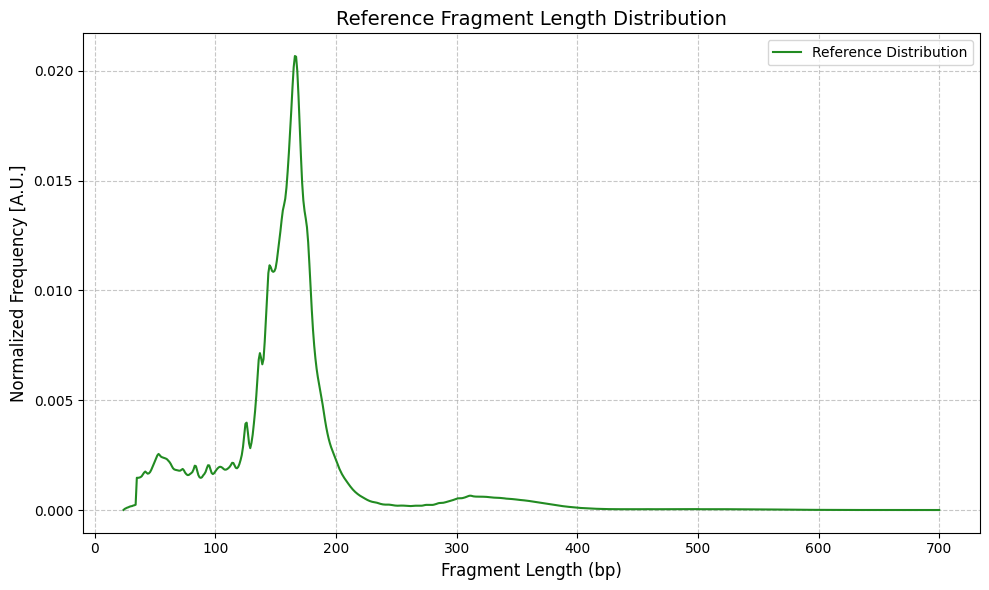

In [5]:
reference_data = pd.read_csv('reference.hist', sep='\t', header=None, 
                             names=['Length', 'Frequency'])

plt.figure(figsize=(10, 6))
plt.plot(reference_data['Length'], reference_data['Frequency'], 
         color='forestgreen', linewidth=1.5, label='Reference Distribution')
plt.xlabel('Fragment Length (bp)', fontsize=12)
plt.ylabel('Normalized Frequency [A.U.]', fontsize=12)
plt.title('Reference Fragment Length Distribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

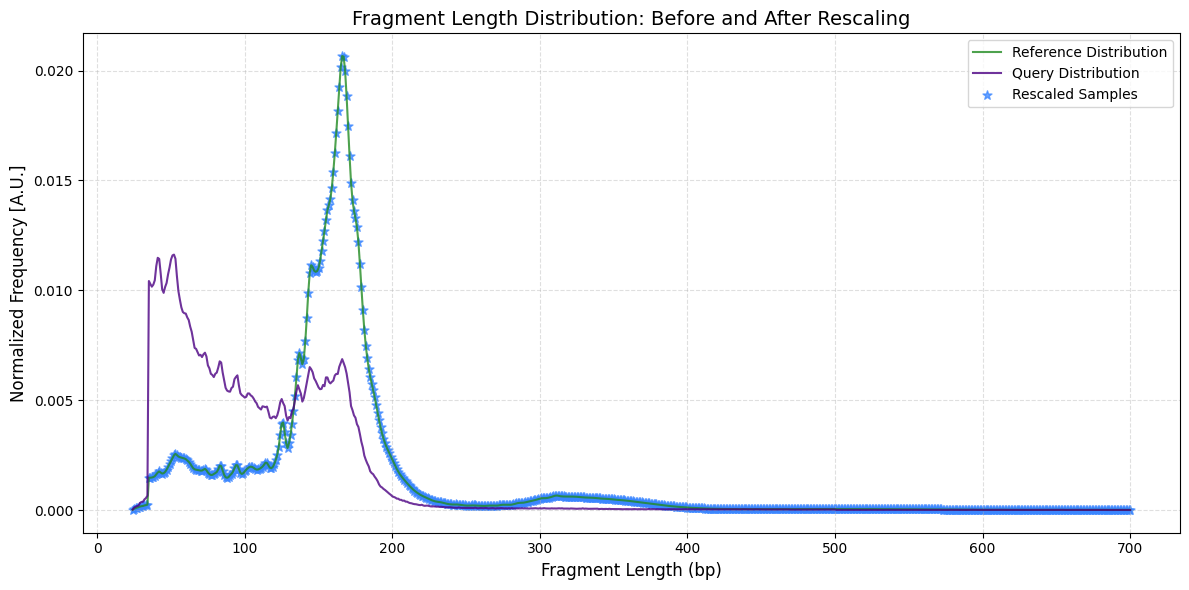

In [6]:
step_size = 10
lower_bound = 0
upper_bound = 720
bin_boundaries = list(range(lower_bound, upper_bound + step_size, step_size))
bin_names = [f"{start}-{start+step_size}" for start in range(lower_bound, upper_bound, step_size)]

fragment_distribution['bin_category'] = pd.cut(
    fragment_distribution['Fragment_Length'],
    bins=bin_boundaries, 
    labels=bin_names, 
    right=False 
)

reference_data['bin_category'] = pd.cut(
    reference_data['Length'],
    bins=bin_boundaries, 
    labels=bin_names, 
    right=False
)

query_frequencies = fragment_distribution['bin_category'].value_counts().sort_index()
reference_frequencies = reference_data['bin_category'].value_counts().sort_index()

rescaled_fragments = []

for bin_name in bin_names:
    query_bin_size = query_frequencies.get(bin_name, 0)
    reference_bin_size = reference_frequencies.get(bin_name, 0)
    
    target_samples = min(query_bin_size, reference_bin_size)
    if target_samples > 0:
        bin_fragments = reference_data[reference_data['bin_category'] == bin_name]
        
        sampled_fragments = bin_fragments.sample(n=target_samples, random_state=456)
        rescaled_fragments.append(sampled_fragments)

rescaled_distribution = pd.concat(rescaled_fragments, ignore_index=True)

plt.figure(figsize=(12, 6))

plt.plot(reference_data['Length'], reference_data['Frequency'], 
         color='forestgreen', label='Reference Distribution', linewidth=1.5, alpha=0.8)
plt.plot(fragment_distribution['Fragment_Length'], fragment_distribution['Normalized_Frequency'], 
         color='indigo', label='Query Distribution', linewidth=1.5, alpha=0.8)

plt.scatter(rescaled_distribution['Length'], rescaled_distribution['Frequency'], 
           color='#3A86FF', label='Rescaled Samples', marker='*', s=45, alpha=0.75)

plt.xlabel('Fragment Length (bp)', fontsize=12)
plt.ylabel('Normalized Frequency [A.U.]', fontsize=12)
plt.title('Fragment Length Distribution: Before and After Rescaling', fontsize=14)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()